In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA

df_train = pd.read_csv("TADPOLE_D1_D2_BL_RF_TRAIN.csv")
df_test = pd.read_csv("TADPOLE_D1_D2_BL_RF_TEST.csv")

def preprocess_data(df):
    df = df[df["DX"].isin([0, 1, 4])].copy()
    
    mapping = {4: "NL", 1: "MCI", 0: "AD"}
    df["DX"] = df["DX"].map(mapping)
    
    cols_to_drop = ['DX', 'PTID', 'EXAMDATE']
    
    X = df.drop(cols_to_drop, axis=1)
    y = df["DX"]
    
    return X, y

X_train, y_train = preprocess_data(df_train)
X_test, y_test = preprocess_data(df_test)

print("Distribución de clases TRAIN:")
print(y_train.value_counts())
print("\nDistribución de clases TEST:")
print(y_test.value_counts())

Distribución de clases TRAIN:
DX
MCI    691
NL     417
AD     269
Name: count, dtype: int64

Distribución de clases TEST:
DX
MCI    173
NL     104
AD      67
Name: count, dtype: int64



ENTRENANDO MODELO SVM NORMAL (SIN PCA)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

[Resultados SVM Normal]
Mejores hiperparámetros: {'feature_select__k': 50, 'svm__C': 100, 'svm__gamma': 0.001}
Classification Report:
               precision    recall  f1-score   support

          AD       0.81      0.87      0.83        67
         MCI       0.86      0.67      0.75       173
          NL       0.69      0.90      0.78       104

    accuracy                           0.78       344
   macro avg       0.78      0.81      0.79       344
weighted avg       0.80      0.78      0.78       344



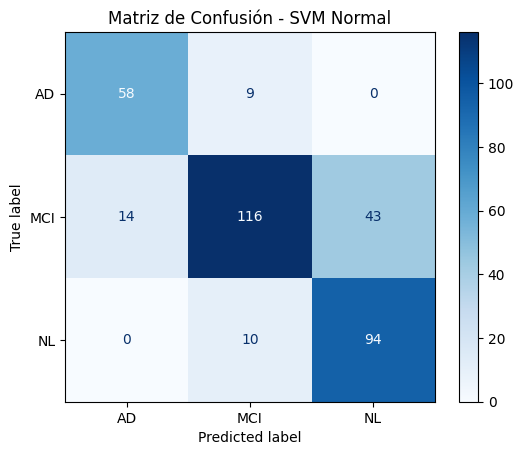

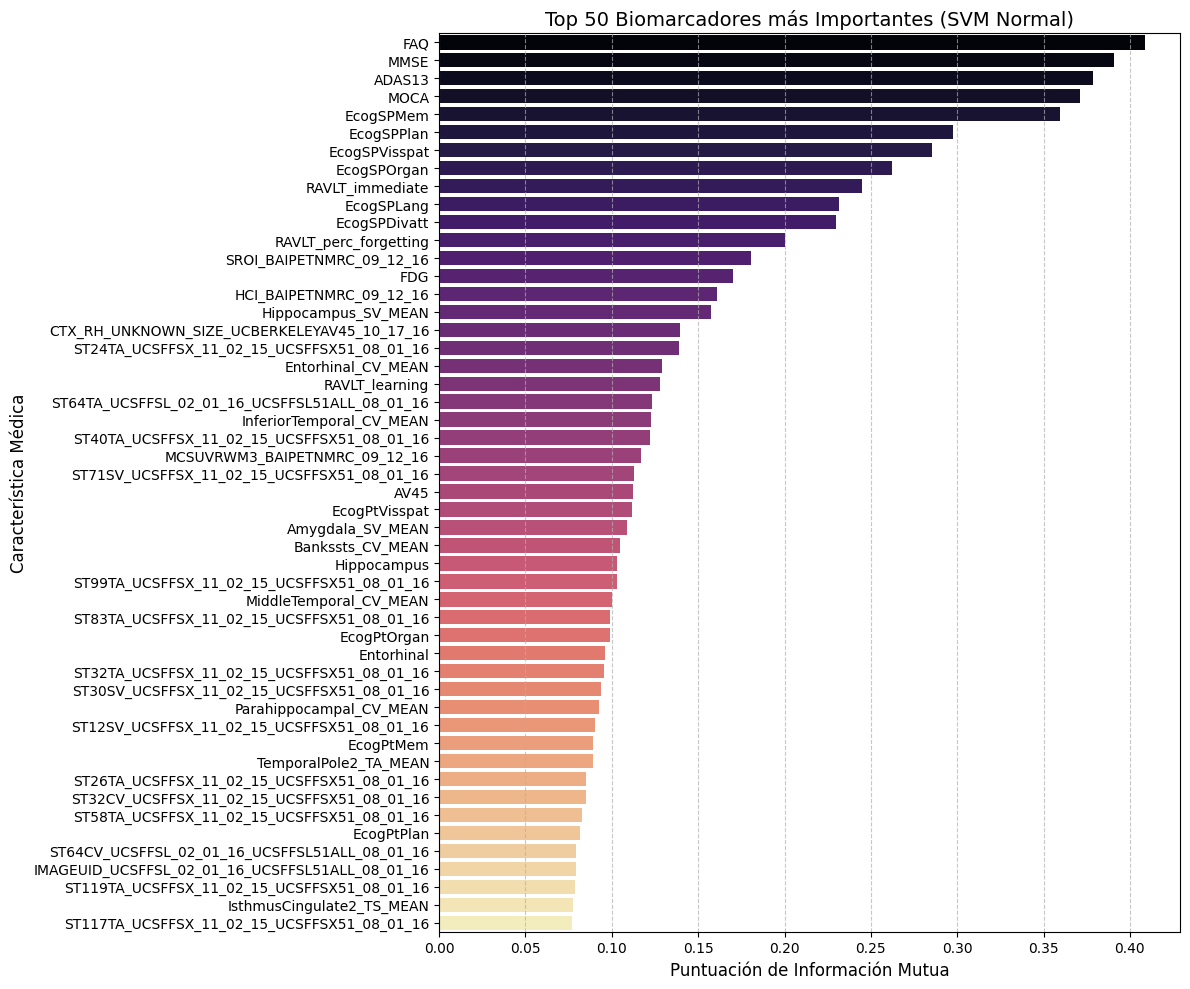

¡Modelo normal empaquetado y guardado como 'SVM.pkl'!


In [ ]:
print("\n" + "="*50)
print("ENTRENANDO MODELO SVM NORMAL (SIN PCA)")
print("="*50)

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_select", SelectKBest(score_func=mutual_info_classif)),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

param_grid_svm = {
    "feature_select__k": [50, 100, 150],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.001]
}

scoring = {"f1": "f1_macro", "precision": "precision_macro", "recall": "recall_macro"}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print("\n[Resultados SVM Normal]")
print("Mejores hiperparámetros:", grid_svm.best_params_)
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=best_svm.classes_)
disp_svm.plot(cmap="Blues")
plt.title("Matriz de Confusión - SVM Normal")
plt.show()

selector_svm = best_svm.named_steps["feature_select"]
df_importancias = pd.DataFrame({
    'Caracteristica': X_train.columns,
    'Importancia (Mutual Info)': selector_svm.scores_
})

top_50_features = df_importancias.sort_values(by='Importancia (Mutual Info)', ascending=False).head(50)

plt.figure(figsize=(12, 10))
sns.barplot(
    x='Importancia (Mutual Info)', 
    y='Caracteristica', 
    data=top_50_features, 
    hue='Caracteristica', 
    palette='magma', 
    legend=False
)
plt.title('Top 50 Biomarcadores más Importantes (SVM Normal)', fontsize=14)
plt.xlabel('Puntuación de Información Mutua', fontsize=12)
plt.ylabel('Característica Médica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Guardar Modelo
joblib.dump(best_svm, 'SVM.pkl')
print("¡Modelo normal empaquetado y guardado como 'SVM.pkl'!")


ENTRENANDO MODELO SVM CON PCA
Fitting 5 folds for each of 108 candidates, totalling 540 fits

[Resultados SVM con PCA]
Mejores hiperparámetros: {'feature_select__k': 50, 'pca__n_components': 30, 'svm__C': 100, 'svm__gamma': 0.001}
Classification Report:
               precision    recall  f1-score   support

          AD       0.78      0.91      0.84        67
         MCI       0.88      0.66      0.75       173
          NL       0.69      0.90      0.78       104

    accuracy                           0.78       344
   macro avg       0.78      0.82      0.79       344
weighted avg       0.80      0.78      0.78       344



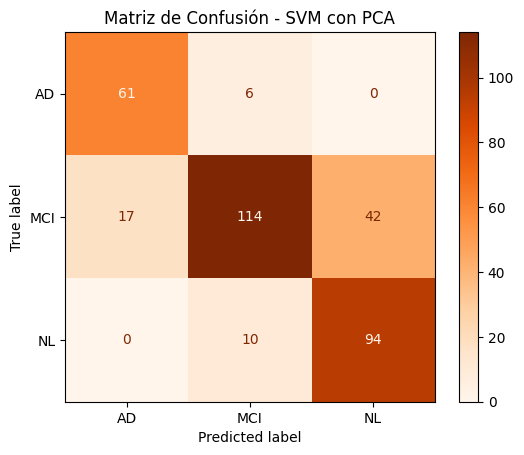

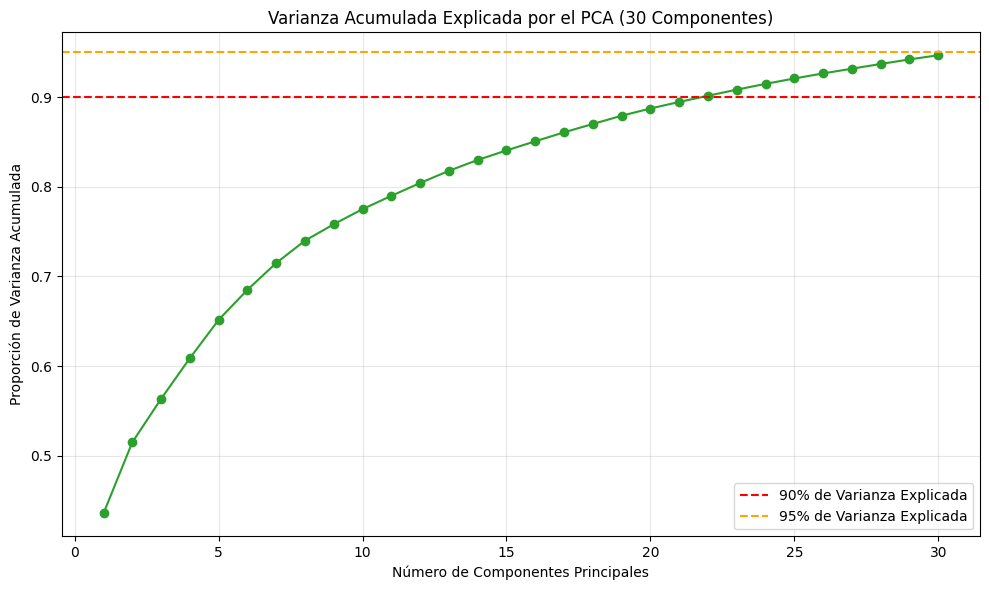

¡Modelo con PCA empaquetado y guardado como 'SVM_con_PCA.pkl'!


In [ ]:
print("\n" + "="*50)
print("ENTRENANDO MODELO SVM CON PCA")
print("="*50)

pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_select", SelectKBest(score_func=mutual_info_classif)),
    ("pca", PCA()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

param_grid_pca = {
    "feature_select__k": [50, 100, 150],
    "pca__n_components": [20, 30, 40], # Valores siempre menores o iguales a 'k'
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.001]
}

grid_pca = GridSearchCV(
    pipeline_pca,
    param_grid_pca,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1,
    verbose=1
)

grid_pca.fit(X_train, y_train)
best_svm_pca = grid_pca.best_estimator_
y_pred_pca = best_svm_pca.predict(X_test)

# Tabla de resultados
print("\n[Resultados SVM con PCA]")
print("Mejores hiperparámetros:", grid_pca.best_params_)
print("Classification Report:\n", classification_report(y_test, y_pred_pca))

# Matriz de confusión
cm_pca = confusion_matrix(y_test, y_pred_pca)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=best_svm_pca.classes_)
disp_pca.plot(cmap="Oranges")
plt.title("Matriz de Confusión - SVM con PCA")
plt.show()

pca_step = best_svm_pca.named_steps["pca"]
varianza_acumulada = np.cumsum(pca_step.explained_variance_ratio_)

n_components_pca = pca_step.n_components_
k_features = best_svm_pca.named_steps["feature_select"].k

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-', color='#2ca02c')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% de Varianza Explicada')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% de Varianza Explicada')
plt.title(f"Varianza Acumulada Explicada por el PCA ({n_components_pca} Componentes)")
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Proporción de Varianza Acumulada")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(best_svm_pca, 'SVM_con_PCA.pkl')
print("¡Modelo con PCA empaquetado y guardado como 'SVM_con_PCA.pkl'!")